## Exercicio 1

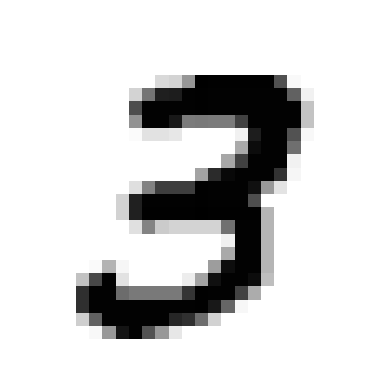

Testando imagem do 3: [False]
Matriz de Confusão:
[[8978   12]
 [ 453  557]]
Acurácia: 0.9535
Precisão: 0.9789
Sensibilidade (Recall): 0.5515


In [7]:
from sklearn.datasets import fetch_openml
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X, y = mnist['data'], mnist['target']
y = y.astype(np.uint8)

posicao_do_tres = np.where(y == 3)[0][0]

digito_3 = X[posicao_do_tres]
plt.imshow(digito_3.reshape(28, 28), cmap='binary')
plt.axis('off')
plt.show()

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

y_train_3 = (y_train == 3)
y_test_3 = (y_test == 3)

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_3)

print("Testando imagem do 3:", sgd_clf.predict([digito_3]))

y_pred = sgd_clf.predict(X_test)

print(f"Matriz de Confusão:{confusion_matrix(y_test_3, y_pred)}")
print(f"Acurácia: {accuracy_score(y_test_3, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test_3, y_pred):.4f}")
print(f"Sensibilidade (Recall): {recall_score(y_test_3, y_pred):.4f}")

# Exercicio 2

In [13]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_excel('EficiênciaVeículos.xlsx')

X = df[['Peso (kg)']]
y = df['Eficiência (km/l)']

modelo = LinearRegression()
modelo.fit(X, y)

coef_angular = modelo.coef_[0]
coef_linear = modelo.intercept_

print(f"Coeficiente Angular (m): {coef_angular:.6f}")
print(f"Coeficiente Linear (b):  {coef_linear:.6f}")
print(f"Equação da reta: Eficiência = ({coef_angular:.6f} * Peso) + {coef_linear:.6f}")

peso_novo = pd.DataFrame({'Peso (kg)': [1300]})
predicao = modelo.predict(peso_novo)[0]

print(f"A eficiência estimada para um veículo de 1.300 kg é: {predicao:.2f} km/l")

Coeficiente Angular (m): -0.004282
Coeficiente Linear (b):  14.278120
Equação da reta: Eficiência = (-0.004282 * Peso) + 14.278120
A eficiência estimada para um veículo de 1.300 kg é: 8.71 km/l
